# CNN model

In [7]:
import os
import numpy as np
from keras.preprocessing.image import ImageDataGenerator, save_img
from keras.utils import to_categorical

# Load dataset
data = np.load('data.npy')  # Shape: (num_samples, height, width, channels)
target = np.load('target.npy')  # Shape: (num_samples, num_classes)

# Directory to save augmented images 
save_dir = 'augmented_images'
os.makedirs(save_dir, exist_ok=True)

# Data augmentation settings
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

num_augmented_images = 4  # Number of augmented images per original image
augmented_data = []
augmented_target = []

# Loop through all classes
num_classes = target.shape[1]  # Number of classes in one-hot encoded target
for class_idx in range(num_classes):
    # Filter images belonging to the current class
    class_data = data[np.argmax(target, axis=1) == class_idx]
    print(f"Processing class {class_idx}, {class_data.shape[0]} images.")

    # Augment images for the current class
    for img_array in class_data:
        img_array = np.expand_dims(img_array, axis=0)  # Expand dimensions to (1, height, width, channels)
        augmented_iter = datagen.flow(img_array, batch_size=1)
        
        # Generate augmented images
        for _ in range(num_augmented_images):
            aug_img = next(augmented_iter)[0]
            augmented_data.append(aug_img)
            augmented_target.append(to_categorical(class_idx, num_classes=num_classes))
            
            # Optionally save augmented images for inspection
            save_img(os.path.join(save_dir, f"class_{class_idx}_aug_{len(augmented_data)}.png"), aug_img)

# Convert augmented data to numpy arrays
augmented_data = np.array(augmented_data)
augmented_target = np.array(augmented_target)

# Combine augmented data with the original dataset
data = np.concatenate((data, augmented_data), axis=0)
target = np.concatenate((target, augmented_target), axis=0)

print(f"Final dataset shape: {data.shape}, {target.shape}")


Processing class 0, 400 images.
Processing class 1, 400 images.
Processing class 2, 400 images.
Processing class 3, 400 images.
Processing class 4, 400 images.
Processing class 5, 400 images.
Final dataset shape: (12000, 100, 100, 3), (12000, 6)


In [8]:
from sklearn.model_selection import train_test_split
import numpy as np

# Convert data to float32
data = data.astype(np.float32)
target = target.astype(np.float32)

# Save intermediate splits if memory allows
X_train, X_temp, y_train, y_temp = train_test_split(data, target, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Save data in smaller chunks
np.save('X_train.npy', X_train)
np.save('X_val.npy', X_val)
np.save('X_test.npy', X_test)
np.save('y_train.npy', y_train)
np.save('y_val.npy', y_val)
np.save('y_test.npy', y_test)

print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")


Training set size: 9600
Validation set size: 1200
Testing set size: 1200


In [9]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Activation, Dropout, BatchNormalization
from tensorflow.keras import optimizers, losses
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
import tensorflow as tf


model = Sequential()

model.add(Conv2D(16, (3, 3), input_shape=X_train.shape[1:], padding='same', kernel_initializer='orthogonal'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(32, (5, 5), kernel_initializer='orthogonal'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), kernel_initializer='orthogonal'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(target.shape[1], activation='sigmoid'))

model.compile(loss=losses.binary_crossentropy, optimizer=optimizers.RMSprop(learning_rate=0.001), metrics=['accuracy'])

# Implement callbacks
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model.summary()

datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)



history = model.fit(datagen.flow(X_train, y_train, batch_size=16),
                    epochs=50,
                    validation_data=(X_val, y_val),
                    callbacks=[reduce_lr, early_stopping])


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 100, 100, 16)      448       
                                                                 
 batch_normalization_3 (Bat  (None, 100, 100, 16)      64        
 chNormalization)                                                
                                                                 
 activation_3 (Activation)   (None, 100, 100, 16)      0         
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 50, 50, 16)        0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 46, 46, 32)        12832     
                                                                 
 batch_normalization_4 (Bat  (None, 46, 46, 32)       

Average Training Loss: 0.20857210367918014
Average Training Accuracy: 0.7484374964237213
Average Validation Loss: 0.2085941430926323
Average Validation Accuracy: 0.7545833277702332


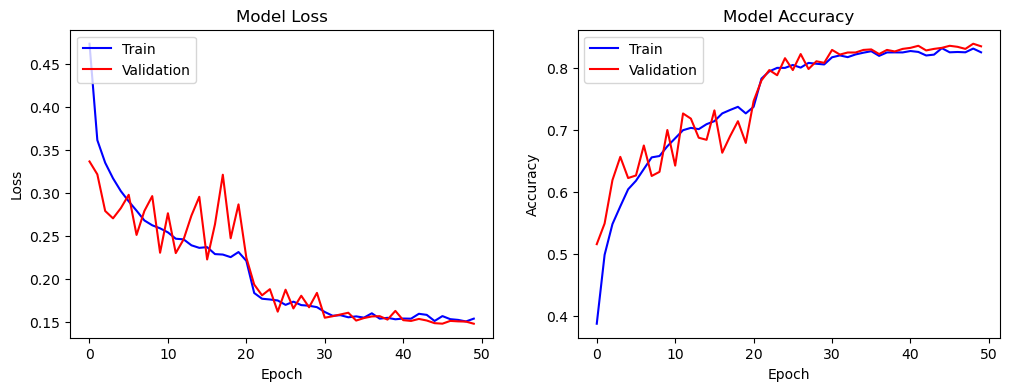

In [10]:


import matplotlib.pyplot as plt

avg_train_loss = np.mean(history.history['loss'])
avg_train_accuracy = np.mean(history.history['accuracy'])
avg_val_loss = np.mean(history.history['val_loss'])
avg_val_accuracy = np.mean(history.history['val_accuracy'])

print("Average Training Loss:", avg_train_loss)
print("Average Training Accuracy:", avg_train_accuracy)
print("Average Validation Loss:", avg_val_loss)
print("Average Validation Accuracy:", avg_val_accuracy)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], 'b')
plt.plot(history.history['val_loss'], 'r')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], 'b')
plt.plot(history.history['val_accuracy'], 'r')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

model.save('my_model.keras')
